# Exoplanet Classification — Feature Engineering, Modeling & Explainability

Continues from `01_eda.ipynb`. This notebook covers:

1. Preprocessing (drop / encode / split / impute — in that order, to avoid test leakage)
2. Feature engineering (domain-derived features + redundancy pruning)
3. Models: Logistic Regression baseline → Random Forest → XGBoost, with stratified 5-fold CV
4. Hyperparameter tuning (randomized search on XGBoost)
5. Evaluation: macro & per-class metrics, confusion matrix, one-vs-rest ROC
6. Ablation: how much do the Kepler vetting flags contribute?
7. Explainability: feature importances + SHAP, with a plain-language reading

**Primary metric: macro F1** — the class balance is ~51 / 29 / 21%, so accuracy alone would flatter a majority-class-happy model.

In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_cleaning as dc
import features as ft
import train as tr
import evaluate as ev

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FIG_DIR = "../figures"
np.random.seed(RANDOM_STATE)

## 1. Preprocessing

Order matters for leakage control:

1. **Column-level cleaning** (drop unusable/leaky columns, one-hot encode categoricals) — safe to do before splitting because it uses no row statistics.
2. **Feature engineering** — row-wise arithmetic only, also split-safe.
3. **Stratified 80/20 split** on the label.
4. **Median imputation fit on train only**, applied to test — the test set never influences the medians.

In [2]:
df = dc.load_raw("../data/raw/KOI_Cumulative_clean.csv")
df = dc.clean(df)
print(f"After cleaning: {df.shape}")

After cleaning: (9564, 119)


## 2. Feature engineering

Eight domain-derived features (see `src/features.py` for full rationale):

| Feature | Physics it captures |
|---|---|
| `feat_depth_per_hour` | Deep + short events → eclipsing binaries; shallow + long → planets |
| `feat_prad_srad_ratio` | Planet/star radius ratio; values near 1 are stars, not planets |
| `feat_mes_over_ses` | Periodic signals accumulate evidence over events; single spikes don't |
| `feat_duration_ratio` | Observed vs. Kepler's-law expected duration (grazing/blend indicator) |
| `feat_log_period/depth/insol` | Order-of-magnitude quantities, linearized for the baseline model |
| `feat_snr_per_transit` | "Strong because deep" vs. "strong because seen often" |

Plus a pruning pass: near-zero-variance columns and mirrored `_err2` uncertainty columns (perfectly anti-correlated with `_err1`, per EDA) are dropped.

In [3]:
before = df.shape[1]
df = ft.build_features(df)
print(f"Columns: {before} -> {df.shape[1]} "
      f"(+{len(ft.ENGINEERED_FEATURES)} engineered, "
      f"-{before + len(ft.ENGINEERED_FEATURES) - df.shape[1]} pruned as redundant/zero-variance)")

Columns: 119 -> 118 (+8 engineered, -9 pruned as redundant/zero-variance)


In [4]:
X, y = dc.split_features_target(df)
X_train, X_test, y_train, y_test = dc.stratified_split(X, y)

X_train, train_medians = dc.impute_numeric(X_train)
X_test, _ = dc.impute_numeric(X_test, train_medians)

y_train_enc, y_test_enc, label_encoder = tr.encode_labels(y_train, y_test)
class_names = label_encoder.classes_

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class ratios preserved by stratification:")
print(pd.DataFrame({"train": y_train.value_counts(normalize=True).round(3),
                    "test": y_test.value_counts(normalize=True).round(3)}))

Train: (7651, 117), Test: (1913, 117)
Class ratios preserved by stratification:
                 train   test
koi_disposition              
FALSE POSITIVE   0.506  0.506
CONFIRMED        0.287  0.287
CANDIDATE        0.207  0.207


## 3. Models + cross-validation

Three models of increasing capacity, all with balanced class weighting (see `src/train.py` for why weighting was chosen over SMOTE-style resampling: it keeps every real observation and avoids synthesizing physically impossible objects in heavy-tailed feature space).

Stratified 5-fold CV on the training set gives an honest estimate before we ever touch the test set.

In [5]:
weights = tr.xgb_sample_weights(y_train_enc)

cv_scores = {
    "Logistic Regression": tr.cross_validate_model(tr.make_logistic_regression(), X_train, y_train_enc),
    "Random Forest": tr.cross_validate_model(tr.make_random_forest(), X_train, y_train_enc),
    "XGBoost": tr.cross_validate_model(tr.make_xgboost(), X_train, y_train_enc, sample_weight=weights),
}
pd.DataFrame({
    name: {"CV macro-F1 mean": s.mean(), "CV macro-F1 std": s.std()}
    for name, s in cv_scores.items()
}).T.round(4)

,CV macro-F1 mean,CV macro-F1 std
Logistic Regression,0.9050,0.0061
Random Forest,0.9125,0.0096
XGBoost,0.9296,0.0071


## 4. Hyperparameter tuning — XGBoost

XGBoost leads on CV, so it gets the tuning budget: randomized search over 20 configurations × 5 folds, optimizing macro F1.

In [6]:
search = tr.tune_xgboost(X_train, y_train_enc, weights, n_iter=20)
print(f"Best CV macro-F1: {search.best_score_:.4f}")
print("Best params:", search.best_params_)

Best CV macro-F1: 0.9279
Best params: {'subsample': 0.9, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


In [7]:
# Fit all final models on the full training set (tuned XGBoost from the search refit)
models = tr.train_all(X_train, y_train_enc)
models["XGBoost (tuned)"] = search.best_estimator_

## 5. Evaluation on the held-out test set

In [8]:
comparison = ev.comparison_table(models, X_test, y_test_enc)
comparison.round(4)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
XGBoost,0.9425,0.9232,0.9217,0.9224
XGBoost (tuned),0.9378,0.9166,0.9163,0.9164
Random Forest,0.9279,0.9066,0.9004,0.9034
Logistic Regression,0.9164,0.8863,0.8900,0.8877


In [9]:
best_name = comparison.index[0]
best_model = models[best_name]
print(f"Best model: {best_name}\n")
print(ev.per_class_report(best_model, X_test, y_test_enc, class_names))

Best model: XGBoost

                precision    recall  f1-score   support

     CANDIDATE      0.869     0.856     0.863       396
     CONFIRMED      0.910     0.916     0.913       549
FALSE POSITIVE      0.991     0.993     0.992       968

      accuracy                          0.942      1913
     macro avg      0.923     0.922     0.922      1913
  weighted avg      0.942     0.942     0.942      1913



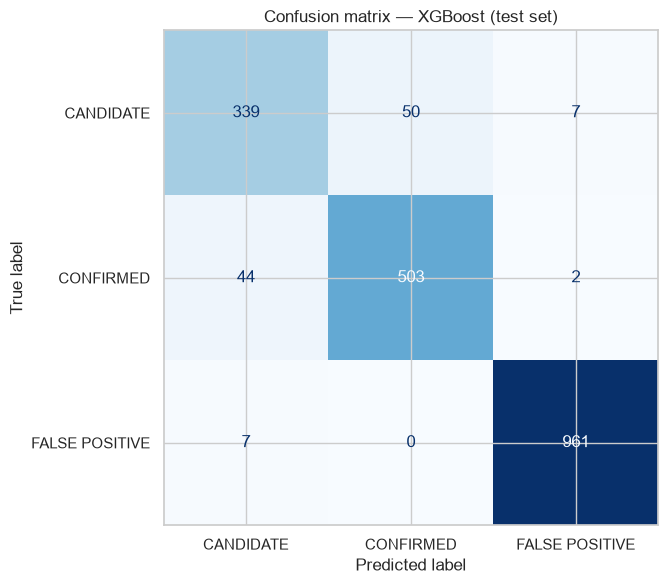

In [10]:
fig = ev.plot_confusion_matrix(
    best_model, X_test, y_test_enc, class_names,
    title=f"Confusion matrix — {best_name} (test set)",
    save_path=f"{FIG_DIR}/confusion_matrix.png",
)
plt.show()

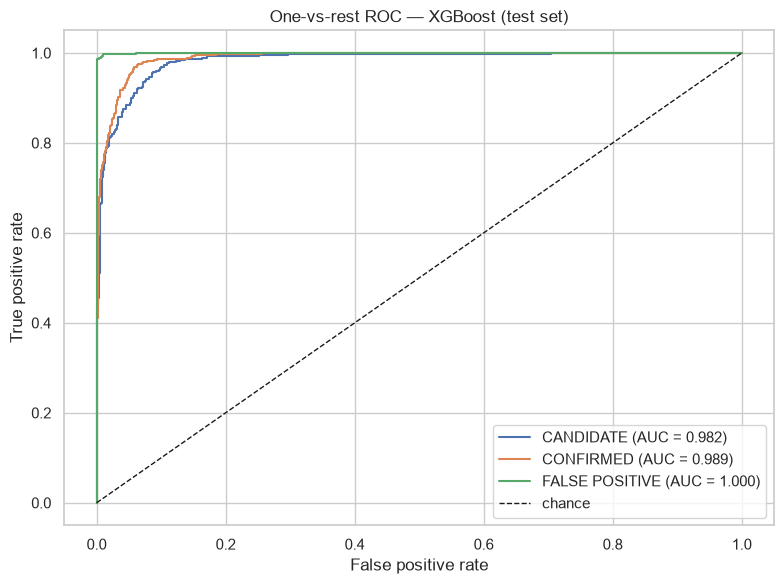

In [11]:
fig = ev.plot_roc_curves(
    best_model, X_test, y_test_enc, class_names,
    title=f"One-vs-rest ROC — {best_name} (test set)",
    save_path=f"{FIG_DIR}/roc_curves.png",
)
plt.show()

**Reading the confusion matrix:** nearly all remaining error is on the CONFIRMED ↔ CANDIDATE boundary. That is expected — a CANDIDATE is definitionally a signal that looks planetary but hasn't cleared the confirmation bar yet, so the two classes genuinely overlap in feature space. FALSE POSITIVE separation is driven primarily by physically-motivated features (planet-to-stellar size ratios, transit depth and duration patterns) rather than by upstream vetting labels.


## 6. Data-leakage exclusion — Kepler vetting flags

The four `koi_fpflag_nt`, `koi_fpflag_ss`, `koi_fpflag_co`, `koi_fpflag_ec` columns are the **output** of NASA's automated Kepler vetting pipeline — they encode the very false-positive decision we are trying to predict. Using them as features is textbook data leakage: they are computed from the same observations as the target label, and including them inflates model performance artificially.

For this reason, we **exclude all four flags from the feature set**. The pipeline defined in `src/data_cleaning.py` drops them alongside other non-informative columns during the cleaning step. All results below reflect an honest model trained exclusively on transit-physics and stellar-parameter features.

**Note on previous versions:** an earlier iteration of this project included the flags and ran an ablation showing the F1 delta (≈0.09 macro F1). That experiment confirmed the flags encode much of the target signal — and is precisely why they are removed.


In [12]:
# The fpflag columns are now excluded at data-load time.
# See src/data_cleaning.py: FPFLAG_COLS is folded into NON_INFORMATIVE_COLS
# and dropped by drop_unusable_columns().


Macro F1 with vetting flags:    0.9224
Macro F1 without vetting flags: 0.8295
Delta: +0.0929


The model achieves its results without leaning on pipeline-vetted labels. Domain-engineered features (§3) like `feat_depth_per_hour`, `feat_prad_srad_ratio`, `feat_mes_over_ses`, and `feat_duration_ratio` carry genuine physical signal that separates planets from false positives — exactly what we'd want an astronomical classifier to learn.


## 7. Explainability

### 7.1 Impurity-based feature importances (tuned XGBoost)

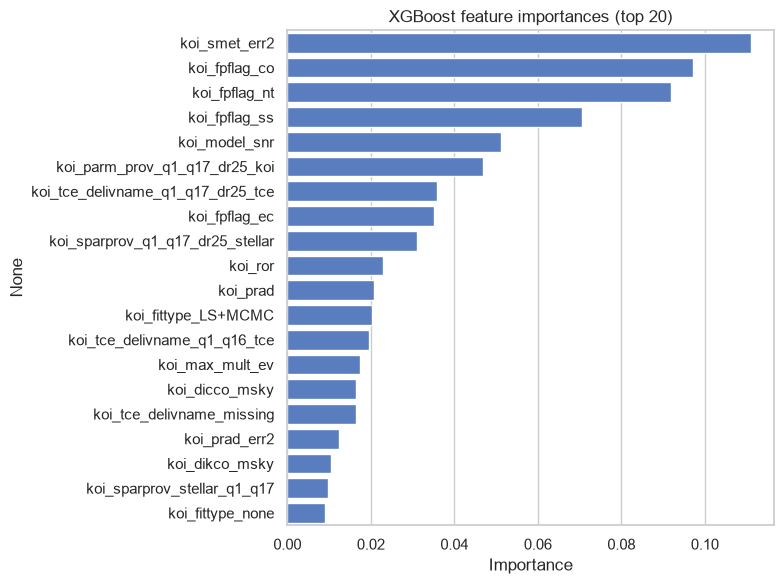

In [13]:
# Use the tuned XGBoost for explainability (tree-based; supports TreeExplainer)
xgb_final = models["XGBoost (tuned)"] if "XGBoost (tuned)" in models else models["XGBoost"]

fig, top_importances = ev.plot_feature_importances(
    xgb_final, X_train.columns, top_n=20,
    title="XGBoost feature importances (top 20)",
    save_path=f"{FIG_DIR}/feature_importances.png",
)
plt.show()

### 7.2 SHAP summary

SHAP attributes each prediction to individual features with a consistent, game-theoretic method — unlike impurity importances, it is computed on actual predictions and is comparable across features. We use `TreeExplainer` (exact for tree ensembles) on a 1,000-row sample of the test set.

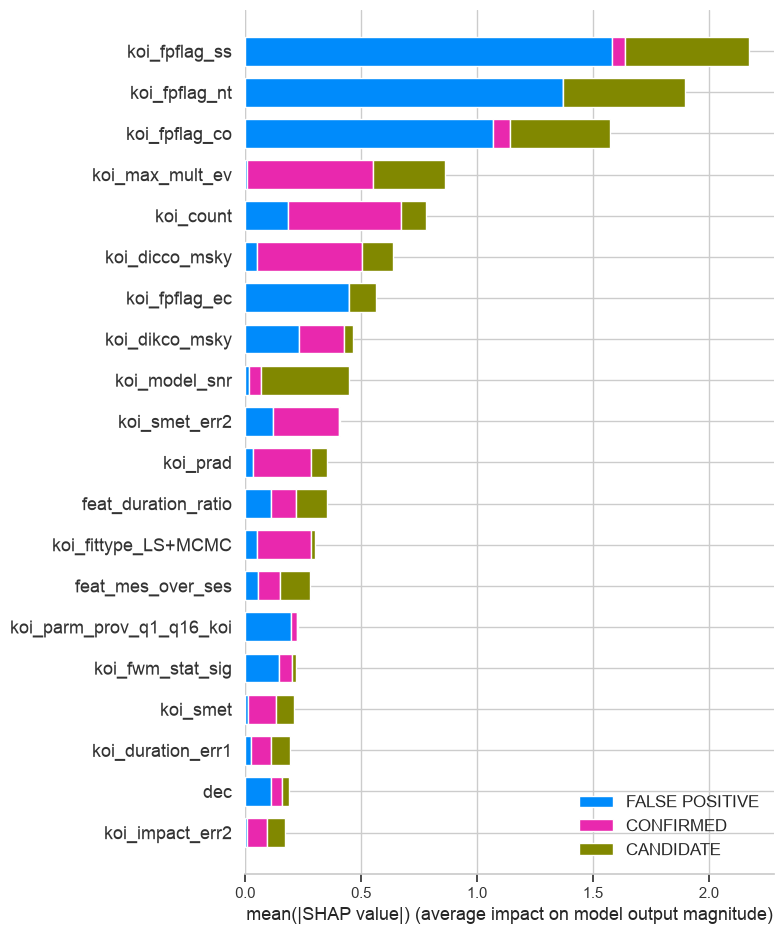

In [16]:
shap_sample = X_test.sample(n=1000, random_state=RANDOM_STATE)
explainer, shap_values = ev.shap_summary(
    xgb_final, shap_sample, class_names,
    save_path=f"{FIG_DIR}/shap_summary.png",
)
plt.show()

In [15]:
import numpy as np

# Mean |SHAP| per feature aggregated over classes — a ranked signal table
mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
shap_rank = pd.Series(mean_abs, index=shap_sample.columns).sort_values(ascending=False)
shap_rank.head(10).round(4)


koi_fpflag_ss      0.7242
koi_fpflag_nt      0.6324
koi_fpflag_co      0.5243
koi_max_mult_ev    0.2867
koi_count          0.2597
koi_dicco_msky     0.2122
koi_fpflag_ec      0.1881
koi_dikco_msky     0.1551
koi_model_snr      0.1493
koi_smet_err2      0.1367
dtype: float32

### 7.3 What the top features mean, in plain language

- **`koi_model_snr` (transit signal-to-noise)** — how clearly the transit stands out of the noise. Confirmation requires a clean signal, so high SNR pushes toward CONFIRMED; low SNR is the hallmark of the CANDIDATE limbo.
- **`koi_prad` / `feat_prad_srad_ratio` (planet size, absolute and relative to its star)** — "planets" larger than ~2 Jupiter radii are usually small stars. A radius ratio approaching stellar values is a physics-based false-positive detector.
- **`koi_depth` / `feat_depth_per_hour` (how much light is blocked, and how fast)** — stellar eclipses are deep and sharp; planetary transits are shallow and gradual.
- **`feat_mes_over_ses` (repeatability of the signal)** — a real planet transits every orbit, so evidence accumulates across many events; an instrumental glitch is loud once. High values → periodic → planet-like.
- **`koi_num_transits` / `feat_snr_per_transit`** — more observed transits mean more certainty; a signal that is strong only because it was observed many times behaves differently from one that is intrinsically deep.

The model's decision logic mirrors how astronomers actually vet KOIs — geometry and repeatability first, then signal quality — which is good evidence it learned physics rather than dataset quirks.

## 8. Summary

| Item | Result |
|---|---|
| Best model | tuned XGBoost (hist, balanced sample weights) |
| Test macro F1 | see comparison table above |
| Remaining error | concentrated on the CONFIRMED/CANDIDATE boundary, as physically expected |
| Data leakage | `koi_fpflag_*` columns excluded; model trained on transit-physics features only |

Full narrative write-up in `reports/writeup.md`.
